# LLM anomaly benchmark: results per re-forecast interval $\mathtt{H}$

Reads every `results/<sweep>/H*/ts*/summary.json` of one sweep. Only cases with a
finished `summary.json` are used; `evaluation.partial.json` is ignored.

Aggregation across series is **macro**: each series first gets its own metric, then all
series count equally. Plots show the median over series (line) with its IQR
(band), one color per $\mathtt{H}$.

- Time to detection is undefined for a series that detected nothing at a slope, so
  those series are left out of that point's statistics.
- False alarms come from the clean series, so each case has one rate that does not
  depend on slope. Upstream counts them per time step, not per alarm episode.

In [1]:
import json
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SWEEP = "full_chronos2_small"
RESULTS_DIR = Path("results") / SWEEP
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

SINGLE_COL = (3.5, 2.5)
DOUBLE_COL = (6.5, 3.5)

mpl.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "font.family": "serif",
    "text.usetex": True,
    "pgf.rcfonts": False,
    "pgf.preamble": r"\usepackage{amsfonts}\usepackage{amssymb}\usepackage{amsmath}",
    "lines.linewidth": 1,
    "figure.figsize": SINGLE_COL,
    "font.size": 9,
    "savefig.dpi": 300,
})

# One size for every figure; constrained layout (not a tight bbox) keeps the saved size fixed.
FIGSIZE = (5.0, SINGLE_COL[1])


def save(fig, name):
    for ext in ("pgf", "pdf", "svg"):
        fig.savefig(FIGURES_DIR / f"{SWEEP}_{name}.{ext}")

In [2]:
rows = []
for path in sorted(RESULTS_DIR.glob("H*/ts*/summary.json")):
    summary = json.loads(path.read_text())
    for row in summary["multi_realization_evaluation"]:
        rows.append({"series": summary["series"], "H": summary["llm_horizon"], **row})
frame = pd.DataFrame(rows)

horizons = sorted(frame["H"].unique())
slopes = sorted(frame["anomaly_magnitude"].unique())
frame.groupby("H")["series"].nunique().rename("num_series").to_frame().T

H,3,6,13,26,52,104,208
num_series,10,10,10,10,10,10,10


In [3]:
def across_series(frame, column, by):
    """Median and IQR over series, NaNs skipped."""

    grouped = frame.groupby(by)[column]
    return pd.DataFrame({
        "median": grouped.median(),
        "q25": grouped.quantile(0.25),
        "q75": grouped.quantile(0.75),
        "n": grouped.count(),
    })


COLORS = dict(zip(horizons, plt.cm.tab10.colors))


def plot_vs_slope(column, ylabel):
    fig, ax = plt.subplots(figsize=FIGSIZE, layout="constrained")
    for horizon in horizons:
        stats = across_series(frame[frame["H"] == horizon], column, "anomaly_magnitude")
        ax.fill_between(stats.index, stats["q25"], stats["q75"], color=COLORS[horizon],
                        alpha=0.15, lw=0)
        ax.plot(stats.index, stats["median"], color=COLORS[horizon], label=rf"$\mathtt{{H}}={horizon}$")
    # Log scale keeps spacing proportional while leaving room to label every tested magnitude.
    ax.set_xscale("log")
    ax.set_xticks(slopes)
    ax.set_xticklabels([f"{m:g}" for m in slopes])
    ax.minorticks_off()
    ax.set_xlabel(r"Anomaly magnitude (u/year)")
    ax.set_ylabel(ylabel)
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=4, frameon=False)
    return fig, ax

## Probability of detection per slope

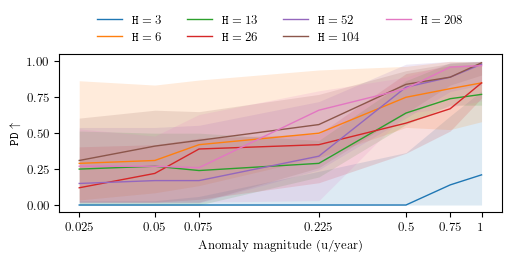

anomaly_magnitude,0.025,0.050,0.075,0.225,0.500,0.750,1.000
H,,,,,,,
3,0.00,0.00,0.00,0.00,0.00,0.14,0.21
6,0.29,0.31,0.42,0.50,0.75,0.81,0.85
13,0.25,0.27,0.24,0.29,0.64,0.74,0.77
26,0.12,0.22,0.39,0.42,0.57,0.67,0.85
52,0.15,0.17,0.17,0.34,0.82,0.89,0.98
104,0.31,0.41,0.45,0.56,0.84,0.89,0.99
208,0.27,0.27,0.26,0.66,0.81,0.96,0.97


In [8]:
fig, ax = plot_vs_slope("probability_of_detection", r"\texttt{PD} $\uparrow$")
ax.set_ylim(-0.05, 1.05)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
save(fig, "pod_vs_slope")
plt.show()

across_series(frame, "probability_of_detection", ["H", "anomaly_magnitude"])["median"].unstack().round(2)

## Time to detection per slope

Per-series value is the mean time to detection over its detected realizations; `n` is
how many series detected at least once at that slope.

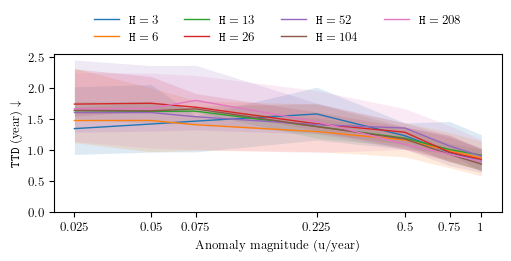

median                                         n        \
anomaly_magnitude  0.025 0.050 0.075 0.225 0.500 0.750 1.000 0.025 0.050   
H                                                                          
3                   1.35  1.42  1.47  1.59  1.24  0.97  0.83     3     3   
6                   1.48  1.48  1.41  1.30  1.17  0.99  0.88     8     8   
13                  1.64  1.63  1.63  1.38  1.20  1.01  0.92     6     6   
26                  1.75  1.76  1.70  1.43  1.29  0.97  0.85     7     7   
52                  1.61  1.61  1.54  1.41  1.36  1.07  0.91     7     7   
104                 1.65  1.64  1.67  1.38  1.18  0.93  0.78     7     7   
208                 1.67  1.68  1.81  1.46  1.10  0.93  0.83     7     7   

                                                 
anomaly_magnitude 0.075 0.225 0.500 0.750 1.000  
H                                                
3                     3     4     4     5     5  
6                     8     8    10    10    10  
13                    6     8    10    10    10  
26                    7     8    10    10    10  
52                    7     9    10    10    10  
104                   7     8    10    10    10  
208                   7     7     9    10    10

In [5]:
fig, ax = plot_vs_slope("time_to_detection_years_mean", r"\texttt{TTD} (year) $\downarrow$")
ax.set_ylim(bottom=0)
save(fig, "ttd_vs_slope")
plt.show()

ttd = across_series(frame, "time_to_detection_years_mean", ["H", "anomaly_magnitude"])
ttd[["median", "n"]].unstack().round(2)

## Detection score per slope

$\bar{S} = \mathcal{P}_{\mathrm{DET}} \cdot 2^{-\#_{\mathrm{ALM}}(y^{-1})/h}$ with $h = 0.2$:
each false alarm per year beyond $h$ halves the score again. Computed per series
(its own $\mathcal{P}_{\mathrm{DET}}$ at the slope and its own false alarm rate),
then aggregated across series like the other metrics.

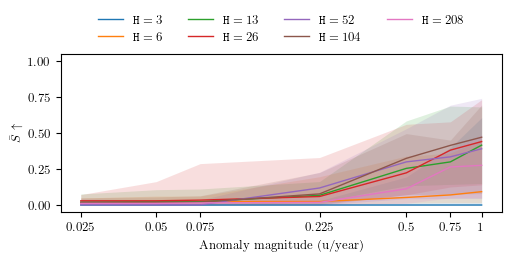

anomaly_magnitude,0.025,0.050,0.075,0.225,0.500,0.750,1.000
H,,,,,,,
3,0.00,0.00,0.00,0.00,0.00,0.00,0.00
6,0.01,0.02,0.02,0.02,0.05,0.07,0.09
13,0.02,0.02,0.02,0.07,0.26,0.30,0.42
26,0.03,0.03,0.03,0.06,0.22,0.38,0.44
52,0.00,0.00,0.00,0.12,0.30,0.34,0.39
104,0.02,0.02,0.02,0.08,0.32,0.42,0.47
208,0.01,0.01,0.01,0.02,0.11,0.27,0.28


In [6]:
SCORE_HALF_LIFE = 0.2  # h, false alarms per year that halve the score

frame["score"] = frame["probability_of_detection"] * 2 ** (
    -frame["false_alarm_rate_per_y"] / SCORE_HALF_LIFE
)

fig, ax = plot_vs_slope("score", r"$\bar{S}$ $\uparrow$")
ax.set_ylim(-0.05, 1.05)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
save(fig, "score_vs_slope")
plt.show()

across_series(frame, "score", ["H", "anomaly_magnitude"])["median"].unstack().round(2)

## False alarm rate per $\mathtt{H}$

One dot per series (jittered horizontally), IQR as a bar, median as a diamond. The
axis is logarithmic, so rates of zero are drawn at the floor `FA_FLOOR`.

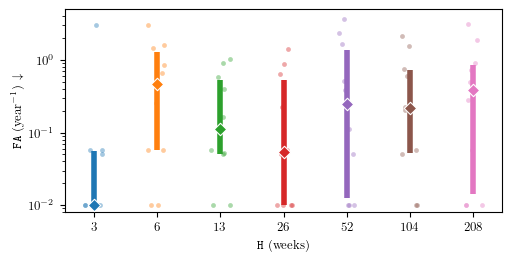

,median,q25,q75,n
H,,,,
3,0.000,0.000,0.055,10
6,0.460,0.057,1.300,10
13,0.111,0.051,0.534,10
26,0.054,0.000,0.535,10
52,0.251,0.013,1.366,10
104,0.217,0.052,0.718,10
208,0.391,0.014,0.865,10


In [7]:
FA_FLOOR = 1e-2

false_alarms = frame.groupby(["H", "series"])["false_alarm_rate_per_y"].first().reset_index()
stats = across_series(false_alarms, "false_alarm_rate_per_y", "H")
rng = np.random.default_rng(0)

fig, ax = plt.subplots(figsize=FIGSIZE, layout="constrained")
for x, horizon in enumerate(horizons):
    color = COLORS[horizon]
    values = false_alarms.loc[false_alarms["H"] == horizon, "false_alarm_rate_per_y"]
    jitter = rng.uniform(-0.15, 0.15, len(values))
    ax.scatter(x + jitter, np.maximum(values, FA_FLOOR), color=color, alpha=0.4, s=12, lw=0)
    ax.vlines(x, max(stats.loc[horizon, "q25"], FA_FLOOR), max(stats.loc[horizon, "q75"], FA_FLOOR),
              color=color, lw=4)
    ax.scatter(x, max(stats.loc[horizon, "median"], FA_FLOOR), color=color, marker="D", s=40,
               edgecolor="white", lw=0.8, zorder=3)
ax.set_yscale("log")
ax.set_ylim(FA_FLOOR * 0.8, None)
ax.set_xticks(range(len(horizons)))
ax.set_xticklabels([str(h) for h in horizons])
ax.set_xlabel(r"$\mathtt{H}$ (weeks)")
ax.set_ylabel(r"\texttt{FA} (year$^{-1}$) $\downarrow$")
save(fig, "false_alarms_vs_horizon")
plt.show()

stats.round(3)